In [1]:
from google.colab import userdata
import os, json

token = userdata.get('KAGGLE_API_TOKEN').strip()

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "rahul193010", "key": token}, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print(os.path.exists('/root/.kaggle/kaggle.json'))

True


In [2]:
!kaggle competitions download -c house-prices-advanced-regression-techniques

100% 199k/199k [00:00<00:00, 55.2MB/s]



In [3]:
!unzip -o house-prices-advanced-regression-techniques.zip -d house_prices_data

Archive:  house-prices-advanced-regression-techniques.zip
  inflating: house_prices_data/data_description.txt  
  inflating: house_prices_data/sample_submission.csv  
  inflating: house_prices_data/test.csv  
  inflating: house_prices_data/train.csv  


In [5]:
import pandas as pd

train = pd.read_csv('house_prices_data/train.csv')
test = pd.read_csv('house_prices_data/test.csv')

print(train.shape)
train[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'HalfBath', 'SalePrice']].head()

(1460, 81)


,GrLivArea,BedroomAbvGr,FullBath,HalfBath,SalePrice
0,1710,3,2,1,208500
1,1262,3,2,0,181500
2,1786,3,2,1,223500
3,1717,3,1,0,140000
4,2198,4,2,1,250000


In [6]:
train['TotalBath'] = train['FullBath'] + 0.5 * train['HalfBath']

X = train[['GrLivArea', 'BedroomAbvGr', 'TotalBath']]
y = train['SalePrice']

print(X.isnull().sum())  # check for missing values

GrLivArea       0
BedroomAbvGr    0
TotalBath       0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 56862.577516079706
Coefficients: [   100.63689525 -26645.53251638  27083.20771296]


In [8]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 53371.56024906056
R² Score: 0.6286307301050608


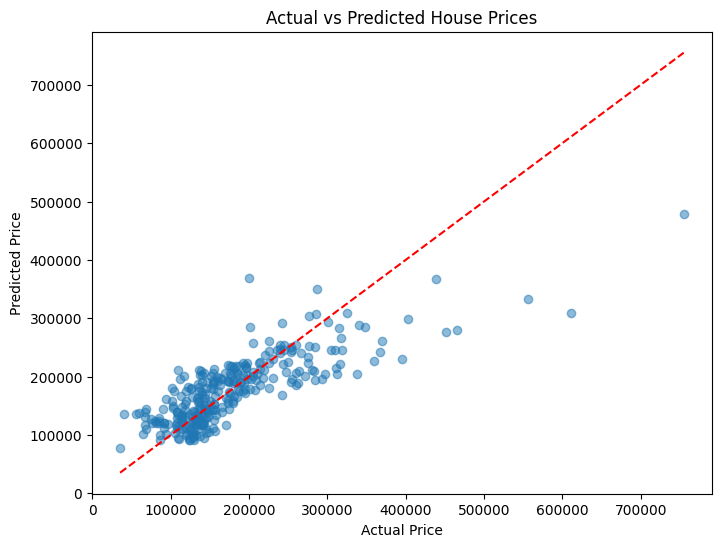

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

## Summary
Built a linear regression model to predict house sale prices using square footage (GrLivArea),
number of bedrooms (BedroomAbvGr), and total bathrooms (FullBath + 0.5*HalfBath).

**Results:**
- RMSE: ~$53,371
- R² Score: 0.629

The model captures general trends well for mid-range homes but underestimates luxury properties,
as expected given the limited feature set.